In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/joosthazelzet/lego-brick-images/validation.txt
/kaggle/input/datasets/joosthazelzet/lego-brick-images/LEGO brick images v1/3022 Plate 2x2/201706161906-0094.png
/kaggle/input/datasets/joosthazelzet/lego-brick-images/LEGO brick images v1/3022 Plate 2x2/201706161906-0341.png
/kaggle/input/datasets/joosthazelzet/lego-brick-images/LEGO brick images v1/3022 Plate 2x2/201706161906-0363.png
/kaggle/input/datasets/joosthazelzet/lego-brick-images/LEGO brick images v1/3022 Plate 2x2/201706161906-0223.png
/kaggle/input/datasets/joosthazelzet/lego-brick-images/LEGO brick images v1/3022 Plate 2x2/201706161906-0305.png
/kaggle/input/datasets/joosthazelzet/lego-brick-images/LEGO brick images v1/3022 Plate 2x2/201706161906-0245.png
/kaggle/input/datasets/joosthazelzet/lego-brick-images/LEGO brick images v1/3022 Plate 2x2/201706161906-0083.png
/kaggle/input/datasets/joosthazelzet/lego-brick-images/LEGO brick images v1/3022 Plate 2x2/201706161906-0191.png
/kaggle/input/datasets/joo

In [2]:
import tensorflow as tf 
from tensorflow.keras import layers, models, losses, optimizers, metrics 
import matplotlib.pyplot as plt
import numpy as np

2026-02-26 16:04:53.726234: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772121893.911409      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772121893.964030      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772121894.406108      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772121894.406146      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772121894.406149      55 computation_placer.cc:177] computation placer alr

In [3]:
import os
os.listdir("/kaggle/input/lego-brick-images/")

FileNotFoundError: [Errno 2] No such file or directory: '/kaggle/input/lego-brick-images/'

In [ ]:
/kaggle/input/datasets/joosthazelzet/lego-brick-images

In [4]:
train_data = tf.keras.utils.image_dataset_from_directory(
 "/kaggle/input/datasets/joosthazelzet/lego-brick-images",
 labels=None, # pour GAN / autoencodeur
 color_mode="grayscale",
 image_size=(64, 64),
 batch_size=32,
 shuffle=True
)


Found 46384 files.


I0000 00:00:1771681446.565374      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1771681446.571365      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


# Normalisation:


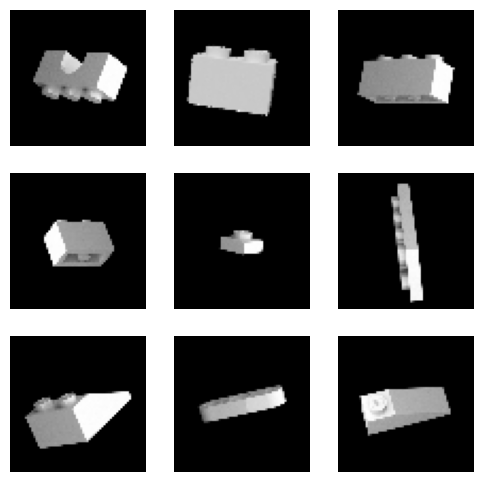

In [5]:
train = train_data.map(lambda x: (x / 127.5) - 1.0)

for batch in train_data.take(1):
    images = batch[:9]
    plt.figure(figsize=(6,6))
    for i in range(9):
        plt.subplot(3,3,i+1)
        plt.imshow(images[i].numpy().squeeze(), cmap="gray")
        plt.axis("off")
    plt.show()

- 9 briques LEGO
- redimensionnées en 64×64

# Création du Générateur

In [7]:
discriminator_input = layers.Input(shape=(64, 64, 1))
x = layers.Conv2D(64, kernel_size=4, strides=2, padding="same", use_bias = False)(discriminator_input)
x = layers.LeakyReLU(0.2)(x)
x = layers.Dropout(0.3)(x)
x = layers.Conv2D(128, kernel_size=4, strides=2, padding="same", use_bias = False)(x)
x = layers.BatchNormalization(momentum = 0.9)(x)
x = layers.LeakyReLU(0.2)(x)
x = layers.Dropout(0.3)(x)
x = layers.Conv2D(256, kernel_size=4, strides=2, padding="same", use_bias = False)(x)
x = layers.BatchNormalization(momentum = 0.9)(x)
x = layers.LeakyReLU(0.2)(x)
x = layers.Dropout(0.3)(x)
x = layers.Conv2D(512, kernel_size=4, strides=2, padding="same", use_bias = False)(x)
x = layers.BatchNormalization(momentum = 0.9)(x)
x = layers.LeakyReLU(0.2)(x)
x = layers.Dropout(0.3)(x)
x = layers.Conv2D( 1, kernel_size=4, strides=1, padding="valid", use_bias = False, activation = 'sigmoid')(x)
discriminator_output = layers.Flatten()(x)
discriminator = models.Model(discriminator_input, discriminator_output)
discriminator.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 64, 64, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 64)     │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 128)    │       131,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 256)      │       524,288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 4, 4, 512)      │     2,097,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 4, 4, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 4, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 4, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 1, 1, 1)        │         8,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,765,312 (10.55 MB)

 Trainable params: 2,763,520 (10.54 MB)

 Non-trainable params: 1,792 (7.00 KB)

# Création du Discriminateur

In [8]:
generator_input = layers.Input(shape=(100,))
x = layers.Reshape((1, 1, 100))(generator_input)
x = layers.Conv2DTranspose(
     512, kernel_size=4, strides=1, padding="valid", use_bias = False)(x) 
x = layers.BatchNormalization(momentum=0.9)(x)
x = layers.LeakyReLU(0.2)(x)
x = layers.Conv2DTranspose(
     256, kernel_size=4, strides=2, padding="same", use_bias = False)(x)
x = layers.BatchNormalization(momentum=0.9)(x)
x = layers.LeakyReLU(0.2)(x)
x = layers.Conv2DTranspose(
     128, kernel_size=4, strides=2, padding="same", use_bias = False)(x)
x = layers.BatchNormalization(momentum=0.9)(x)
x = layers.LeakyReLU(0.2)(x)
x = layers.Conv2DTranspose(
     64, kernel_size=4, strides=2, padding="same", use_bias = False)(x)
x = layers.BatchNormalization(momentum=0.9)(x)
x = layers.LeakyReLU(0.2)(x)
generator_output = layers.Conv2DTranspose(
                     1,
                     kernel_size=4,
                     strides=2,
                     padding="same",
                     use_bias = False,
                     activation = 'tanh')(x)
generator = models.Model(generator_input, generator_output)
generator.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 1, 1, 100)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 4, 4, 512)      │       819,200 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 4, 4, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 4, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 8, 8, 256)      │     2,097,152 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_5 (LeakyReLU)       │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 16, 16, 128)    │       524,288 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_6 (LeakyReLU)       │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_3              │ (None, 32, 32, 64)     │       131,072 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_7 (LeakyReLU)       │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_4              │ (None, 64, 64, 1)      │         1,024 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,576,576 (13.64 MB)

 Trainable params: 3,574,656 (13.64 MB)

 Non-trainable params: 1,920 (7.50 KB)

# Définition des pertes et optimisateurs

Cette partie correspond à la méthode compile() de la classe DCGAN.

In [9]:
def compile(self, d_optimizer, g_optimizer):
    super(DCGAN, self).compile()
    self.loss_fn = losses.BinaryCrossentropy()
    self.d_optimizer = d_optimizer
    self.g_optimizer = g_optimizer
    self.d_loss_metric = metrics.Mean(name="d_loss")
    self.g_loss_metric = metrics.Mean(name="g_loss")

Fonction de perte
On utilise :
BinaryCrossentropy()
Car le discriminateur réalise une classification binaire :
 Image réelle → label = 1
 Image générée → label = 0

Optimisateurs

In [10]:
optimizers.Adam(0.0002, beta_1=0.5)  #beta_1=0.5 → réduit les oscillations adversarial

# Boucle d’entraînement

In [11]:
def train_step(self, real_images):
    batch_size = tf.shape(real_images)[0]
    #.Génération du bruit latent
    random_latent_vectors = tf.random.normal(shape=(batch_size, self.latent_dim))
    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
       #. Génération d’images artificielles
        generated_images = self.generator(random_latent_vectors, training=True)
        #Prédictions du discriminateur
        real_predictions = self.discriminator(real_images, training=True)
        fake_predictions = self.discriminator(generated_images, training=True)
        real_labels = tf.ones_like(real_predictions)
        fake_labels = tf.zeros_like(fake_predictions)
        # .Calcul des pertes
        d_real_loss = self.loss_fn(real_labels, real_predictions)
        d_fake_loss = self.loss_fn(fake_labels, fake_predictions)
        d_loss = (d_real_loss + d_fake_loss) / 2.0
        g_loss = self.loss_fn(real_labels, fake_predictions)
    gradients_of_discriminator = disc_tape.gradient(d_loss, self.discriminator.trainable_variables)
    gradients_of_generator = gen_tape.gradient(g_loss, self.generator.trainable_variables)
    # Mise à jour des poids
    self.d_optimizer.apply_gradients(zip(gradients_of_discriminator, 
    self.discriminator.trainable_variables))
    self.g_optimizer.apply_gradients(zip(gradients_of_generator, 
    self.generator.trainable_variables))
    self.d_loss_metric.update_state(d_loss)
    self.g_loss_metric.update_state(g_loss)
    return {"d_loss": self.d_loss_metric.result(),"g_loss": self.g_loss_metric.result()}

# Lancer l’entraînement

In [12]:
dcgan.fit(
     train, # Dataset tf.data normalisé
     epochs=100,
     callbacks=[gan_monitor]#GANMonitor → affiche les images générées à chaque epoch
)

NameError: name 'dcgan' is not defined

# Résultats attendus
- À chaque epoch, les images générées deviennent progressivement plus nettes et 
ressemblent aux chiffres du dataset.
- Le TP permet de visualiser la progression et comprendre le rôle du générateur et du 
discriminateur.

1. Pourquoi normalise-t-on les images entre [-1, 1] ?
2. Quelle est la différence entre Conv2D et Conv2DTranspose ?
3. Que se passe-t-il si le générateur est trop puissant par rapport au discriminateur ?
4. Comment améliorer la stabilité de l’entraînement ?

Epoch 1/10
1450/1450 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - d_loss: 0.3052 - g_loss: 3.5376

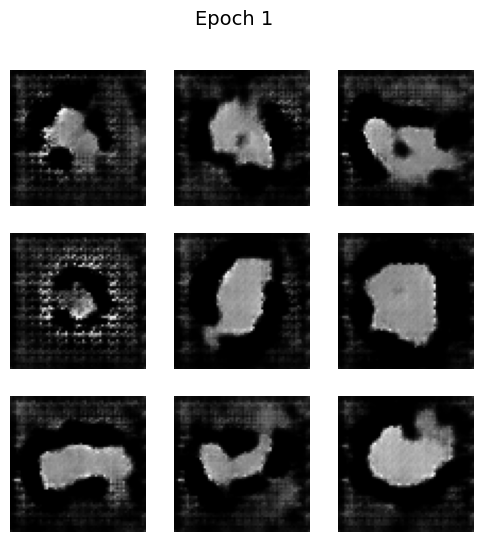

1450/1450 ━━━━━━━━━━━━━━━━━━━━ 68s 38ms/step - d_loss: 0.3051 - g_loss: 3.5375
Epoch 2/10
1449/1450 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - d_loss: 0.3016 - g_loss: 2.9950

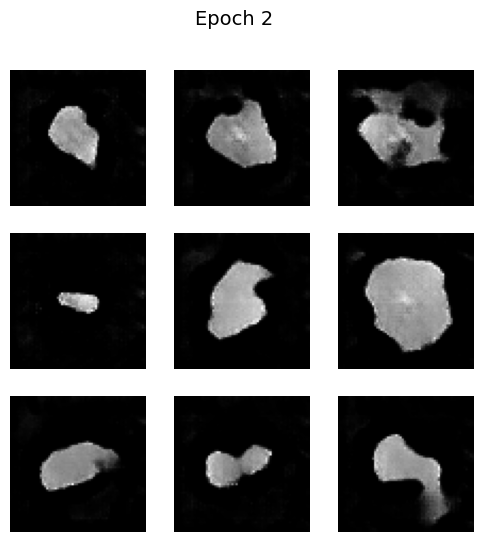

1450/1450 ━━━━━━━━━━━━━━━━━━━━ 47s 32ms/step - d_loss: 0.3016 - g_loss: 2.9949
Epoch 3/10
1449/1450 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - d_loss: 0.2683 - g_loss: 3.0636

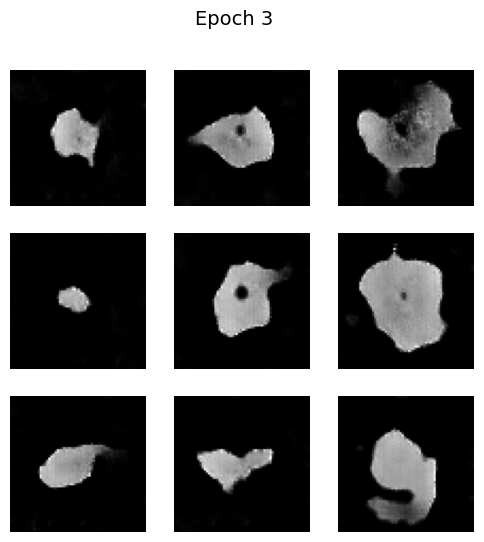

1450/1450 ━━━━━━━━━━━━━━━━━━━━ 47s 32ms/step - d_loss: 0.2683 - g_loss: 3.0637
Epoch 4/10
1449/1450 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - d_loss: 0.2319 - g_loss: 3.3652

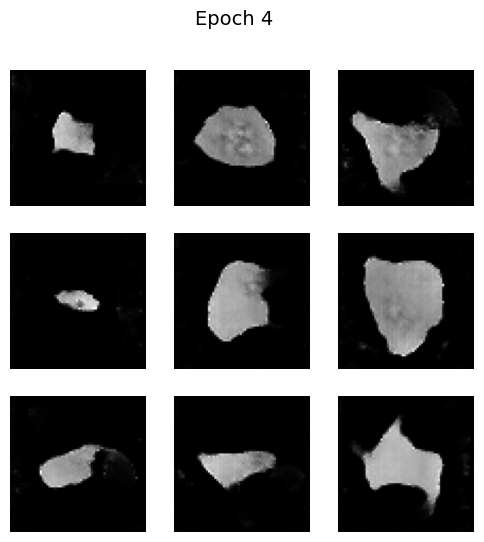

1450/1450 ━━━━━━━━━━━━━━━━━━━━ 47s 32ms/step - d_loss: 0.2319 - g_loss: 3.3653
Epoch 5/10
1449/1450 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - d_loss: 0.2151 - g_loss: 3.5995

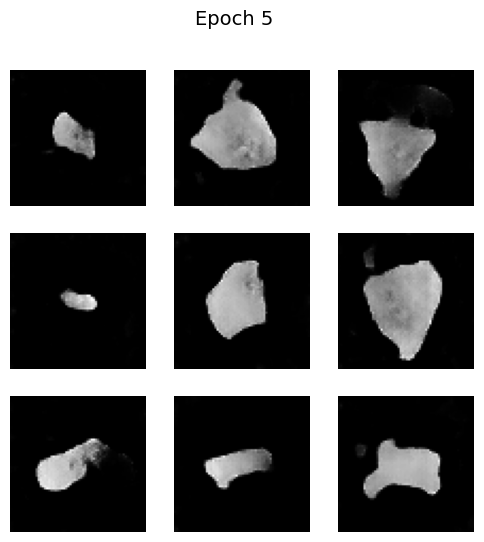

1450/1450 ━━━━━━━━━━━━━━━━━━━━ 47s 32ms/step - d_loss: 0.2151 - g_loss: 3.5995
Epoch 6/10
1450/1450 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - d_loss: 0.1894 - g_loss: 3.8717

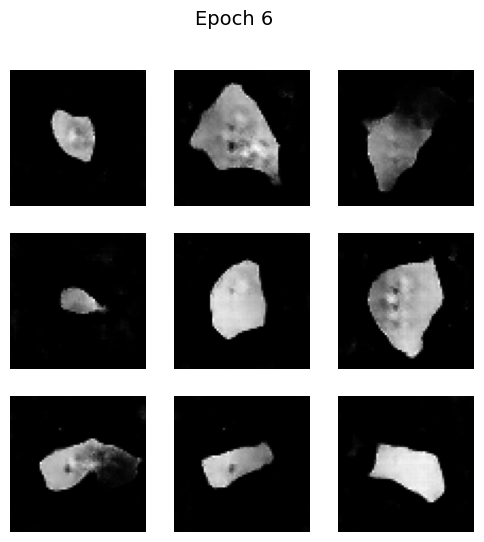

1450/1450 ━━━━━━━━━━━━━━━━━━━━ 47s 33ms/step - d_loss: 0.1894 - g_loss: 3.8718
Epoch 7/10
1449/1450 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - d_loss: 0.1528 - g_loss: 4.1999

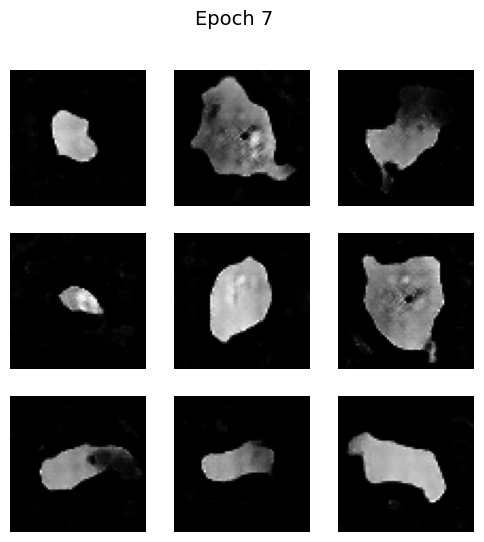

1450/1450 ━━━━━━━━━━━━━━━━━━━━ 47s 32ms/step - d_loss: 0.1528 - g_loss: 4.2000
Epoch 8/10
1449/1450 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - d_loss: 0.1558 - g_loss: 4.2622

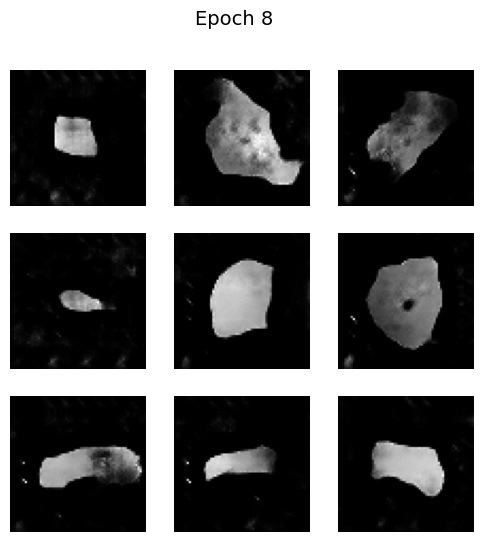

1450/1450 ━━━━━━━━━━━━━━━━━━━━ 47s 32ms/step - d_loss: 0.1558 - g_loss: 4.2623
Epoch 9/10
1449/1450 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - d_loss: 0.1791 - g_loss: 4.3692

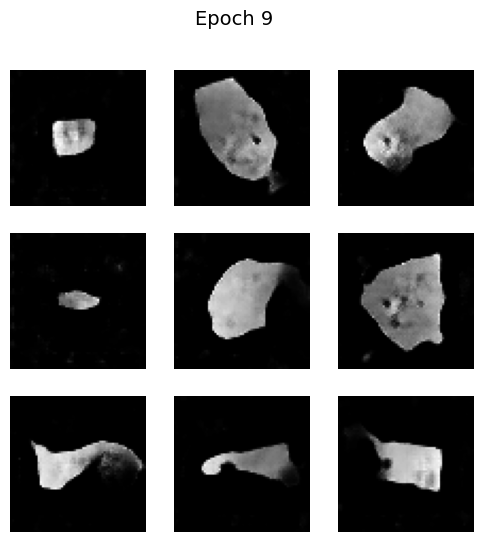

1450/1450 ━━━━━━━━━━━━━━━━━━━━ 47s 32ms/step - d_loss: 0.1791 - g_loss: 4.3692
Epoch 10/10
1449/1450 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - d_loss: 0.1487 - g_loss: 4.4762

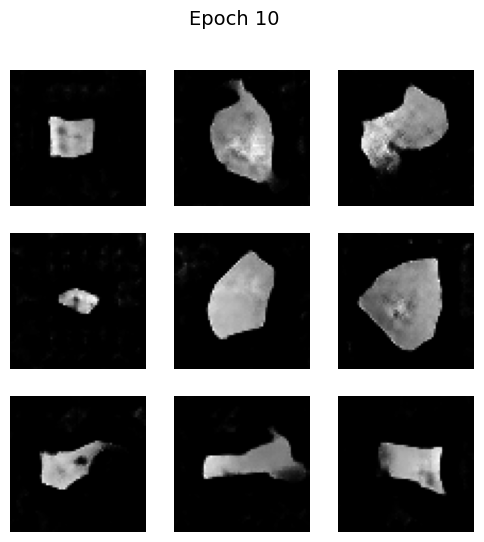

1450/1450 ━━━━━━━━━━━━━━━━━━━━ 47s 32ms/step - d_loss: 0.1487 - g_loss: 4.4763


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models, losses, optimizers, metrics
import matplotlib.pyplot as plt
import numpy as np
# =========================
# DISCRIMINATOR
# =========================
def build_discriminator():
    discriminator_input = layers.Input(shape=(64, 64, 1))
    x = layers.Conv2D(64, 4, 2, "same", use_bias=False)(discriminator_input)
    x = layers.LeakyReLU(0.2)(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Conv2D(128, 4, 2, "same", use_bias=False)(x)
    x = layers.BatchNormalization(momentum=0.9)(x)
    x = layers.LeakyReLU(0.2)(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Conv2D(256, 4, 2, "same", use_bias=False)(x)
    x = layers.BatchNormalization(momentum=0.9)(x)
    x = layers.LeakyReLU(0.2)(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Conv2D(512, 4, 2, "same", use_bias=False)(x)
    x = layers.BatchNormalization(momentum=0.9)(x)
    x = layers.LeakyReLU(0.2)(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Conv2D(1, 4, 1, "valid", use_bias=False, activation="sigmoid")(x)
    output = layers.Flatten()(x)
    return models.Model(discriminator_input, output, name="Discriminator")



# =========================
# GENERATOR
# =========================
def build_generator(latent_dim=100):
    generator_input = layers.Input(shape=(latent_dim,))
    x = layers.Reshape((1, 1, latent_dim))(generator_input)
    x = layers.Conv2DTranspose(512, 4, 1, "valid", use_bias=False)(x)
    x = layers.BatchNormalization(momentum=0.9)(x)
    x = layers.LeakyReLU(0.2)(x)

    x = layers.Conv2DTranspose(256, 4, 2, "same", use_bias=False)(x)
    x = layers.BatchNormalization(momentum=0.9)(x)
    x = layers.LeakyReLU(0.2)(x)

    x = layers.Conv2DTranspose(128, 4, 2, "same", use_bias=False)(x)
    x = layers.BatchNormalization(momentum=0.9)(x)
    x = layers.LeakyReLU(0.2)(x)

    x = layers.Conv2DTranspose(64, 4, 2, "same", use_bias=False)(x)
    x = layers.BatchNormalization(momentum=0.9)(x)
    x = layers.LeakyReLU(0.2)(x)
    
    output = layers.Conv2DTranspose(1, 4, 2, "same", use_bias=False, activation="tanh")(x)
    return models.Model(generator_input, output, name="Generator")


# =========================
# DCGAN CLASS
# =========================
class DCGAN(models.Model):
    def __init__(self, discriminator, generator, latent_dim):
        super(DCGAN, self).__init__()
        self.discriminator = discriminator
        self.generator = generator
        self.latent_dim = latent_dim
    def compile(self, d_optimizer, g_optimizer):
        super(DCGAN, self).compile()
        self.loss_fn = losses.BinaryCrossentropy()
        self.d_optimizer = d_optimizer
        self.g_optimizer = g_optimizer
        self.d_loss_metric = metrics.Mean(name="d_loss")
        self.g_loss_metric = metrics.Mean(name="g_loss")
    @property
    def metrics(self):
        return [self.d_loss_metric, self.g_loss_metric]
    def train_step(self, real_images):
        batch_size = tf.shape(real_images)[0]
        random_latent_vectors = tf.random.normal(shape=(batch_size, self.latent_dim))


        with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
            generated_images = self.generator(random_latent_vectors, training=True)
            real_predictions = self.discriminator(real_images, training=True)
            fake_predictions = self.discriminator(generated_images, training=True)
            real_labels = tf.ones_like(real_predictions)
            fake_labels = tf.zeros_like(fake_predictions)
            d_real_loss = self.loss_fn(real_labels, real_predictions)
            d_fake_loss = self.loss_fn(fake_labels, fake_predictions)
            d_loss = (d_real_loss + d_fake_loss) / 2.0
            g_loss = self.loss_fn(real_labels, fake_predictions)

        gradients_of_discriminator = disc_tape.gradient(d_loss, self.discriminator.trainable_variables)
        gradients_of_generator = gen_tape.gradient(g_loss, self.generator.trainable_variables)
        self.d_optimizer.apply_gradients(zip(gradients_of_discriminator, self.discriminator.trainable_variables))
        self.g_optimizer.apply_gradients(zip(gradients_of_generator, self.generator.trainable_variables))
        
        self.d_loss_metric.update_state(d_loss)
        self.g_loss_metric.update_state(g_loss)
        
        return {"d_loss": self.d_loss_metric.result(),"g_loss": self.g_loss_metric.result()}


# =========================
# CALLBACK POUR AFFICHAGE
# =========================
class GANMonitor(tf.keras.callbacks.Callback):
    def __init__(self, num_images=9, latent_dim=100):
        self.num_images = num_images
        self.latent_dim = latent_dim
        self.seed = tf.random.normal(shape=(num_images, latent_dim))
    def on_epoch_end(self, epoch, logs=None):
        generated_images = self.model.generator(self.seed, training=False)
        # Re-scale [-1,1] → [0,1]
        generated_images = (generated_images + 1) / 2.0
        plt.figure(figsize=(6, 6))
        for i in range(self.num_images):
            plt.subplot(3, 3, i + 1)
            plt.imshow(generated_images[i, :, :, 0], cmap="gray")
            plt.axis("off")
        plt.suptitle(f"Epoch {epoch+1}", fontsize=14)
        plt.show()


# =========================
# BUILD MODELS
# =========================
latent_dim = 100
discriminator = build_discriminator()
generator = build_generator(latent_dim)
dcgan = DCGAN(discriminator, generator, latent_dim)
dcgan.compile(
        d_optimizer=optimizers.Adam(0.0002, beta_1=0.5),
        g_optimizer=optimizers.Adam(0.0002, beta_1=0.5)
        )


# =========================
# TRAIN
# =========================
gan_monitor = GANMonitor(num_images=9, latent_dim=latent_dim)
dcgan.fit(
     train, # ton dataset tf.data
     epochs=10,
     callbacks=[gan_monitor]
    )

    

layers.Conv2D(128, 4, 2, "same", use_bias=False)(x)

👉 Couche de convolution 2D
Paramètres :
- 128 → nombre de filtres
      → La couche va apprendre 128 cartes de caractéristiques (feature maps)
- 4 → taille du noyau (kernel_size = 4x4)
- 2 → stride = 2
    → L’image est réduite de moitié (downsampling)
- "same" → padding
    → On garde la taille cohérente (division par le stride uniquement)
- use_bias=False
    → On désactive le biais (souvent inutile quand on utilise BatchNorm juste après)

📌 Cette couche :
- extrait des caractéristiques
- réduit la taille spatiale
- augmente la profondeur (128 canaux)


_________[](http://)

2️⃣ layers.BatchNormalization(momentum=0.9)(x)

👉 Normalisation des activations
BatchNorm :
- stabilise l’entraînement
- accélère la convergence
- réduit le problème du "internal covariate shift"
momentum=0.9   ==  C’est la vitesse de mise à jour de la moyenne mobile utilisée en phase d’inférence.
📌 Pourquoi après Conv2D ?
- Parce qu’on normalise les sorties de la convolution.

3️⃣ layers.LeakyReLU(0.2)(x)

👉 Fonction d’activation

4️⃣ layers.Dropout(0.3)(x)

👉 Régularisation
- 30% des neurones sont désactivés aléatoirement pendant l’entraînement.
- Empêche l’overfitting.

📌 Important :
- Dropout agit seulement pendant le training.

# WGAN

In [ ]:


# =========================
# Discriminateur sans sigmoid
# =========================
def build_discriminator():
    input_img = layers.Input(shape=(64, 64, 1))
    x = layers.Conv2D(64, 4, 2, "same", use_bias=False)(input_img)
    x = layers.LeakyReLU(0.2)(x)
    x = layers.Dropout(0.3)(x)
    
    x = layers.Conv2D(128, 4, 2, "same", use_bias=False)(x)
    x = layers.BatchNormalization(momentum=0.9)(x)
    x = layers.LeakyReLU(0.2)(x)
    x = layers.Dropout(0.3)(x)
    
    x = layers.Conv2D(256, 4, 2, "same", use_bias=False)(x)
    x = layers.BatchNormalization(momentum=0.9)(x)
    x = layers.LeakyReLU(0.2)(x)
    x = layers.Dropout(0.3)(x)
    
    x = layers.Conv2D(512, 4, 2, "same", use_bias=False)(x)
    x = layers.BatchNormalization(momentum=0.9)(x)
    x = layers.LeakyReLU(0.2)(x)
    x = layers.Dropout(0.3)(x)
    
    x = layers.Conv2D(1, 4, 1, "valid", use_bias=False)(x)          # PAS de sigmoid
    output = layers.Flatten()(x)
    return models.Model(input_img, output, name="Critic")


# =========================
# GENERATOR SAME
# =========================
def build_generator(latent_dim=100):
    input_z = layers.Input(shape=(latent_dim,))
    x = layers.Reshape((1, 1, latent_dim))(input_z)
    x = layers.Conv2DTranspose(512, 4, 1, "valid", use_bias=False)(x)
    x = layers.BatchNormalization(momentum=0.9)(x)
    x = layers.LeakyReLU(0.2)(x)
    
    x = layers.Conv2DTranspose(256, 4, 2, "same", use_bias=False)(x)
    x = layers.BatchNormalization(momentum=0.9)(x)
    x = layers.LeakyReLU(0.2)(x)
    
    x = layers.Conv2DTranspose(128, 4, 2, "same", use_bias=False)(x)
    x = layers.BatchNormalization(momentum=0.9)(x)
    x = layers.LeakyReLU(0.2)(x)
    
    x = layers.Conv2DTranspose(64, 4, 2, "same", use_bias=False)(x)
    x = layers.BatchNormalization(momentum=0.9)(x)
    x = layers.LeakyReLU(0.2)(x)
    
    output = layers.Conv2DTranspose(1, 4, 2, "same", use_bias=False, activation="tanh")(x)
    return models.Model(input_z, output, name="Generator")


# =========================
# WGAN avec weight clipping
# =========================
class WGAN(models.Model):
    def __init__(self, discriminator, generator, latent_dim=100, clip_value=0.01, n_critic=5):
        super(WGAN, self).__init__()
        self.discriminator = discriminator
        self.generator = generator
        self.latent_dim = latent_dim
        self.clip_value = clip_value
        self.n_critic = n_critic

    def compile(self, d_optimizer, g_optimizer):
        super(WGAN, self).compile()
        self.d_optimizer = d_optimizer
        self.g_optimizer = g_optimizer
        self.d_loss_metric = metrics.Mean(name="d_loss")
        self.g_loss_metric = metrics.Mean(name="g_loss")

    @property
    def metrics(self):
        return [self.d_loss_metric, self.g_loss_metric]

    def train_step(self, real_images):
        batch_size = tf.shape(real_images)[0]
        z = tf.random.normal((batch_size, self.latent_dim))

        # === Entraîner le critic n fois ===
        for _ in range(self.n_critic):
            with tf.GradientTape() as tape:
                fake_images = self.generator(z, training=True)
                real_scores = self.discriminator(real_images, training=True)
                fake_scores = self.discriminator(fake_images, training=True)
                
                c_loss = -tf.reduce_mean(real_scores) + tf.reduce_mean(fake_scores)

            grads = tape.gradient(d_loss, self.discriminator.trainable_variables)
            self.d_optimizer.apply_gradients(zip(grads, self.discriminator.trainable_variables))

            # Weight clipping (méthode originale WGAN)
            for var in self.discriminator.trainable_variables:
                var.assign(tf.clip_by_value(var, -self.clip_value, self.clip_value))

        # === Générateur ===
        with tf.GradientTape() as tape:
            fake_images = self.generator(z, training=True)
            fake_scores = self.critic(fake_images, training=True)
            g_loss = -tf.reduce_mean(fake_scores)

        grads_g = tape.gradient(g_loss, self.generator.trainable_variables)
        self.g_optimizer.apply_gradients(zip(grads_g, self.generator.trainable_variables))

        self.d_loss_metric.update_state(d_loss)
        self.g_loss_metric.update_state(g_loss)

        return {"d_loss": self.d_loss_metric.result(), "g_loss": self.g_loss_metric.result()}


# =========================
# Callback d'affichage (adapté)
# =========================
class GANMonitor(tf.keras.callbacks.Callback):
    def __init__(self, num_images=9, latent_dim=100):
        self.num_images = num_images
        self.latent_dim = latent_dim
        self.seed = tf.random.normal((num_images, latent_dim))

    def on_epoch_end(self, epoch, logs=None):
        generated = self.model.generator(self.seed, training=False)
        generated = (generated + 1.) / 2.   # [-1,1] → [0,1]
        plt.figure(figsize=(6,6))
        for i in range(self.num_images):
            plt.subplot(3, 3, i+1)
            plt.imshow(generated[i,:,:,0], cmap='gray')
            plt.axis('off')
        plt.suptitle(f"Epoch {epoch+1}")
        plt.show()


# =========================
# Utilisation
# =========================
latent_dim = 100
discriminator = build_discriminator()
generator = build_generator(latent_dim)

wgan = WGAN(discriminator, generator, latent_dim=latent_dim, clip_value=0.01, n_critic=5)

wgan.compile(
    c_optimizer = optimizers.Adam(learning_rate=0.0002, beta_1=0.5),
    g_optimizer = optimizers.Adam(learning_rate=0.0002, beta_1=0.5)
)

# wgan.fit(train_dataset, epochs=50, callbacks=[GANMonitor()])